In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

In [3]:
df = pd.read_csv("C:/Users/SMK/Desktop/the prj/Final_dataset.csv")

In [4]:
df.head()

,Id,Intensity,Steps,MET,Weight,DATE_TIME,Calories
0,1503960366,1,8,2.6,45.559998,2016-03-12 09:59:00,2.07298
1,1503960366,1,8,2.6,45.559998,2016-03-12 10:09:00,2.07298
2,1503960366,1,7,2.6,45.559998,2016-03-12 10:11:00,2.07298
3,1503960366,1,7,2.6,45.559998,2016-03-12 10:12:00,2.07298
4,1503960366,1,11,2.6,45.559998,2016-03-12 10:13:00,2.07298


## <div align='right'>متوجه شدم که  3 تا از ستون های این جدول به کار نمیان و باید حذف بشوند:</div>
	
## 1. Id
## 2. Date_&_Time

In [5]:
df_eddited=df.drop(['Id','DATE_TIME'],axis = 1)

<Axes: >

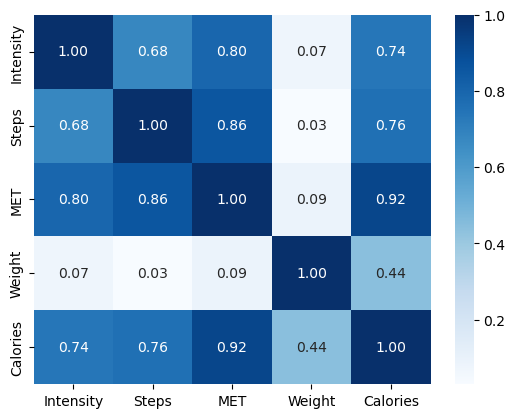

In [6]:
corr = df_eddited.corr()
sns.heatmap(corr , annot=True, fmt='.2f',cmap='Blues')

## <div align='right'> از این جدول برای درک بهتر از ارتباط بین ویژگی های این جدول استفاده کردم.</div>
## <div align='right'> برای ستون (Calories) ارتباط ها رو که چک کردم متوجه شدم هر 4 ویژگی دیگر ارتباط زیادی با ستون هدف دارند.</div>

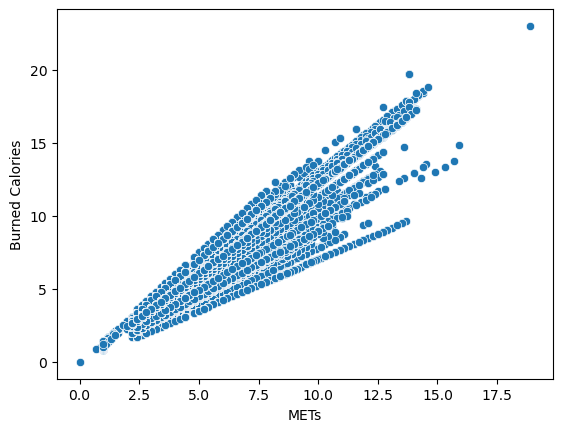

In [7]:
sns.scatterplot(df,x=df.MET,y=df.Calories)
plt.xlabel("METs")
plt.ylabel("Burned Calories")
plt.show()

<div align='right'>  با استفاده از این نمودار متوجه شدم که یکی از دیتا ها از بخش توزیع دیتا خیلی فاصله داره و احتمالا یک داده پرت هست.
و باید بررسی کنم آستانه های حد بالا و پایین دیتا هایم را به دست بیارم و با استفاده از اختلاف حدود بالا و پایین دیتا  دیتای پرت رو از دیتا ست خارج کنم چرا که می خوام  مدل خطی روی دیتا آموزش بدم. </div>

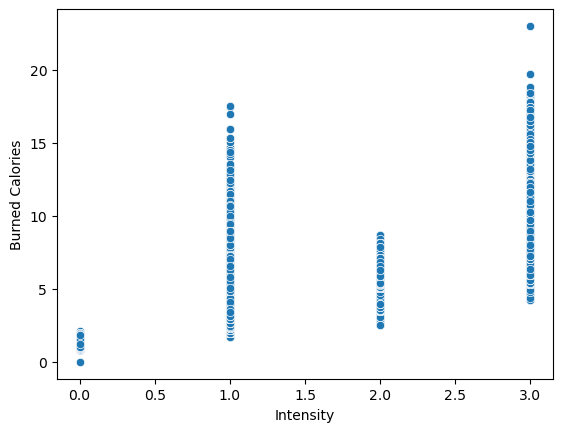

In [8]:
sns.scatterplot(df,x=df.Intensity,y=df.Calories)
plt.xlabel("Intensity")
plt.ylabel("Burned Calories")
plt.show()

<div align='right'> دو مرتبه در دیتا های ستون "فشار" هم  یک داده پرت مشاهده می شود . چون می خوام رگرسون خطی روی دیتاست اعمال کنم باید این داده پرت رو از دیتاستم خارج کنم چرا که مدل رو از یک حالت مایل  نسبت به محدوده توزیع دیتا خارج خواهد کرد.</div>

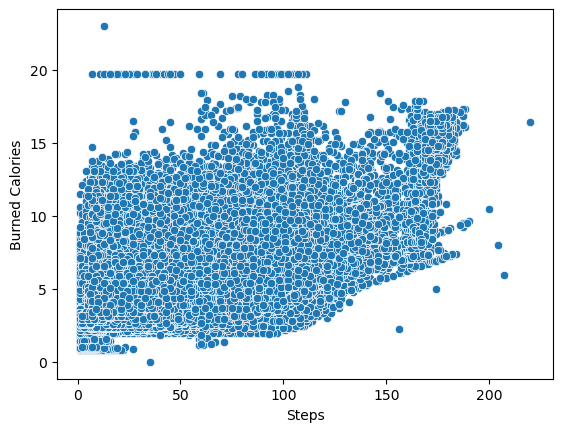

In [9]:
sns.scatterplot(df,x=df.Steps,y=df.Calories)
plt.xlabel("Steps")
plt.ylabel("Burned Calories")
plt.show()

<div align='right'>برای این نموار هم چند مورد دیتا خارج از محدوده توزیع دیتا مشاهده می شود . چون می خوام مدل خطی رو اعمال کنم به مشکل خواهم خورد و عملا مدلم رو به اشتباه می اندازد.
باید حدبالا و حد پایین مدلم رو پیدا کنم و با استفاده از محدود متمرکز توزیع دیتا این دیتا های پرت رو از دیتاستم خارج کنم.</div>

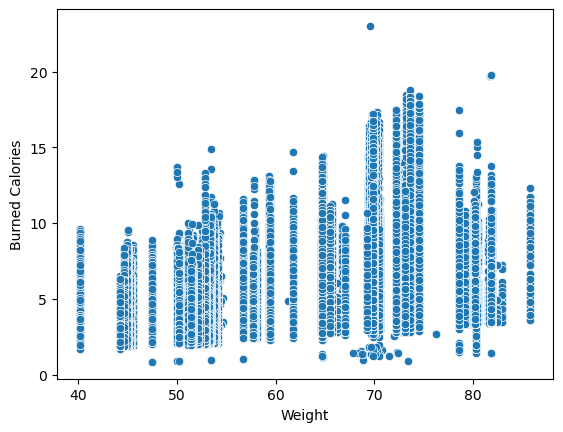

In [10]:
sns.scatterplot(df,x=df.Weight,y=df.Calories)
plt.xlabel("Weight")
plt.ylabel("Burned Calories")
plt.show()

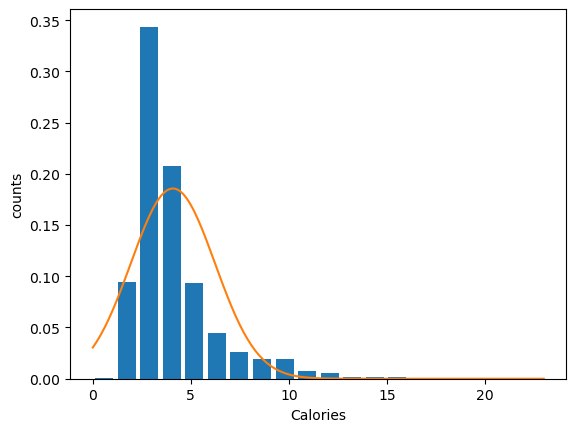

In [11]:
plt.hist(df.Calories,bins=20,rwidth=0.8,density=True)
plt.xlabel("Calories")
plt.ylabel("counts")
rng = np.arange(df_eddited.Calories.min(),df_eddited.Calories.max(),0.1)
plt.plot(rng , norm.pdf(rng,df_eddited.Calories.mean(),df_eddited.Calories.std()))
plt.show()

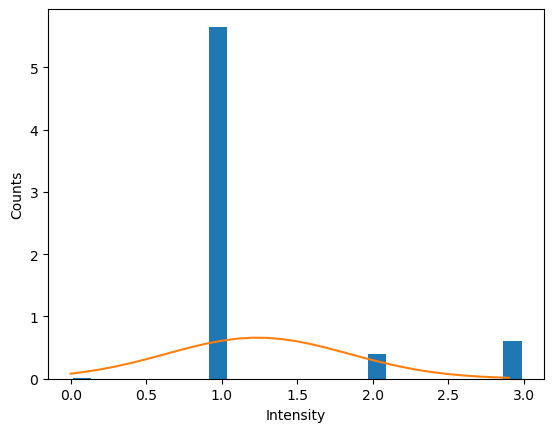

In [12]:
plt.hist(df.Intensity,bins=20,rwidth=0.8,density=True)
plt.xlabel("Intensity")
plt.ylabel("Counts")
rng1 = np.arange(df.Intensity.min(),df.Intensity.max(),0.1)
plt.plot(rng1,norm.pdf(rng1,df.Intensity.mean(),df.Intensity.std()))

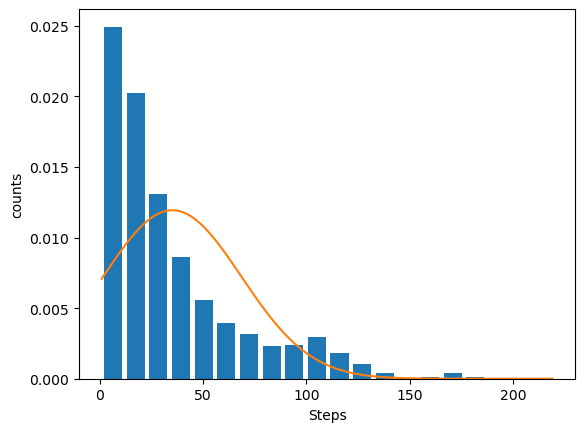

In [13]:
plt.hist(df.Steps,bins=20,rwidth=0.8,density=True)
plt.xlabel("Steps")
plt.ylabel("counts")
rng3= np.arange(df.Steps.min(),df.Steps.max())
plt.plot(rng3,norm.pdf(rng3,df.Steps.mean(),df.Steps.std()))

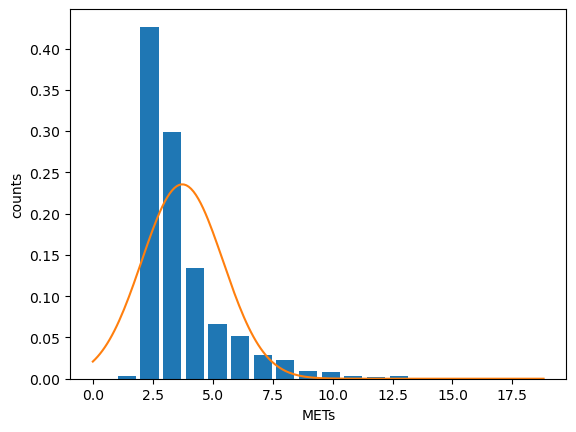

In [14]:
plt.hist(df.MET,rwidth=0.8,bins=20,density=True)
plt.xlabel("METs")
plt.ylabel("counts")
rng4=np.arange(df.MET.min(),df.MET.max(),0.1)
plt.plot(rng4,norm.pdf(rng4,df.MET.mean(),df.MET.std()))
plt.show()

In [15]:
df_eddited.describe()

,Intensity,Steps,MET,Weight,Calories
count,397643.000000,397643.000000,397643.000000,397642.000000,397643.000000
mean,1.237736,35.124069,3.732824,62.018132,4.083713
std,0.604520,33.419461,1.694172,12.394502,2.148640
min,0.000000,1.000000,0.000000,40.154284,0.000000
25%,1.000000,11.000000,2.600000,52.342859,2.682600
50%,1.000000,23.000000,3.200000,59.388569,3.438000
75%,1.000000,47.000000,4.000000,72.211429,4.662600
max,3.000000,220.000000,18.900000,85.800004,23.012640


In [16]:
df.isnull().sum()
df=df.dropna()


In [17]:
df.drop(["Id","DATE_TIME"],axis=1,inplace=True)


In [18]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values


In [19]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.1,random_state=42)
from sklearn.preprocessing import MinMaxScaler ,StandardScaler
mm = MinMaxScaler()
X_train_mm = mm.fit_transform(X_train)
X_test_mm = mm.transform(X_test)
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc_ = sc.transform(X_test)


In [20]:
from sklearn.linear_model import LinearRegression
li_re_mm = LinearRegression()
li_re_sc = LinearRegression()
li_re_mm.fit(X_train_mm,y_train)
y_pred_mm=li_re_mm.predict(X_test_mm)

In [21]:
li_re_sc.fit(X_train_sc,y_train)
y_pred_sc=li_re_sc.predict(X_test_sc_)

In [22]:
from sklearn.metrics import root_mean_squared_error,mean_absolute_error,mean_squared_error,r2_score
def result_score(y_test,y_pred):
    print("R^2 Score :{:.2f} ".format(r2_score(y_test,y_pred)*100))
    print("M S E : ",mean_squared_error(y_test,y_pred))
    print("M A E : ",mean_absolute_error(y_test,y_pred))
    print("R M S E : ",root_mean_squared_error(y_test,y_pred))
    sns.scatterplot(x=y_test , y=y_pred)
    plt.xlabel("y_test")
    plt.ylabel("y_pred")
    plt.show()
    sns.histplot(y_test-y_pred)
    

R^2 Score :97.69 
M S E :  0.10611035267356454
M A E :  0.2054792541670887
R M S E :  0.3257458406082333


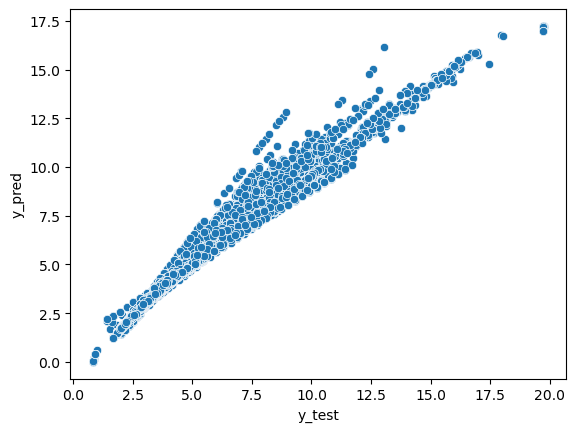

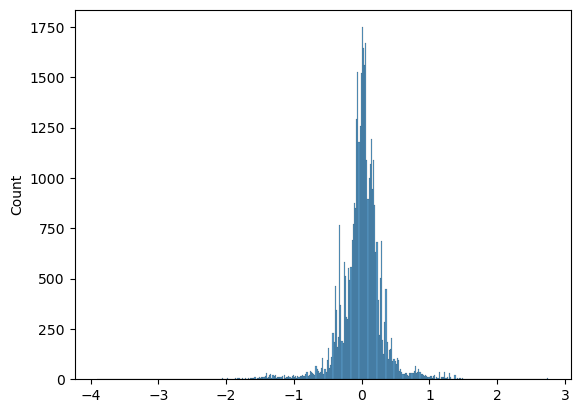

In [23]:
result_score(y_test,y_pred_sc)

R^2 Score :97.69 
M S E :  0.10611035267358476
M A E :  0.20547925416599613
R M S E :  0.32574584060826434


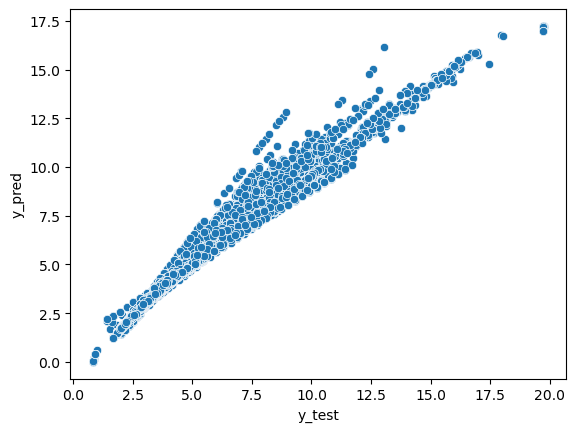

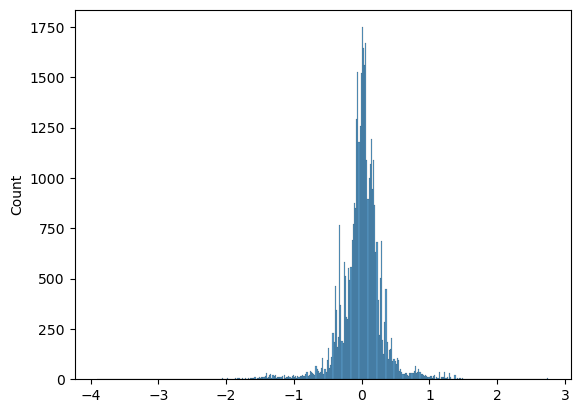

In [24]:
result_score(y_test,y_pred_mm)

In [25]:
import xgboost 
from xgboost import XGBRFRegressor

In [26]:
xgb = XGBRFRegressor(
    n_estimators=500,
    max_depth=9,
    learning_rate=1.0
)

In [27]:
xgb.fit(X_train_sc,y_train)
y_pred_xgb=xgb.predict(X_test_sc_)

R^2 Score :99.95 
M S E :  0.002398418192916113
M A E :  0.03222513562790859
R M S E :  0.048973647943726974


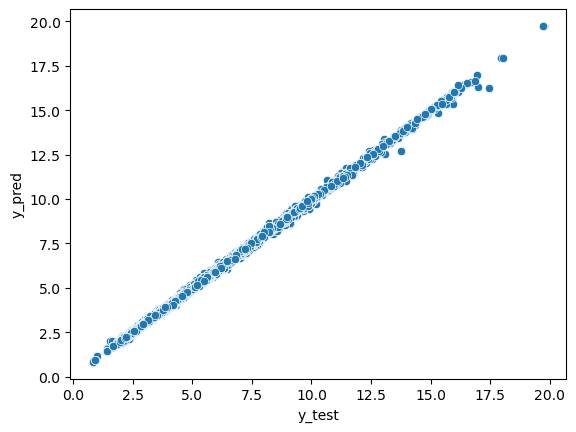

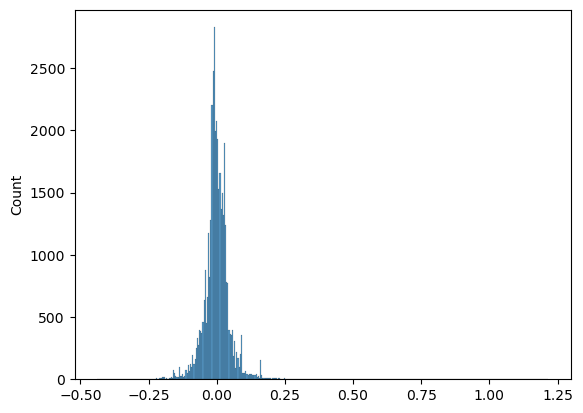

In [28]:
result_score(y_test,y_pred_xgb)

In [46]:
from sklearn.ensemble import GradientBoostingRegressor
gbregressor = GradientBoostingRegressor(
    n_estimators=250,
    learning_rate=1.0,
    max_depth=5
)

In [47]:
gbregressor.fit(X_train_sc,y_train)
y_pred_gb_regressor = gbregressor.predict(X_test_sc_)

R^2 Score :99.99 
M S E :  0.00047413660481772244
M A E :  0.005424520924870525
R M S E :  0.021774678064617223


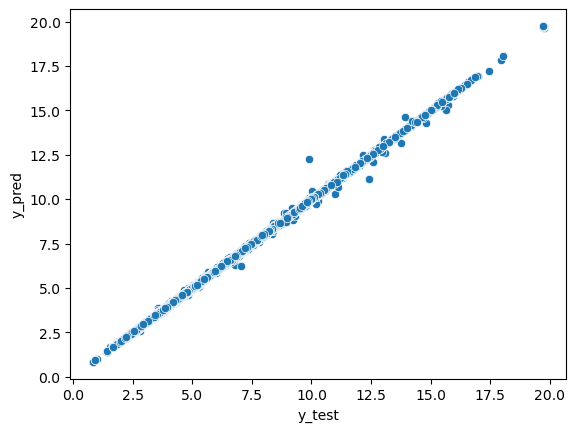

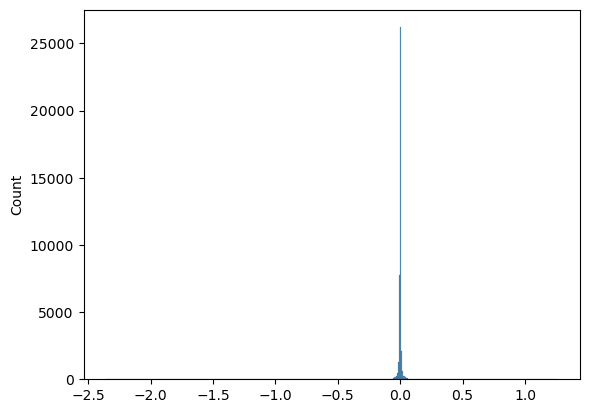

In [48]:
result_score(y_test,y_pred_gb_regressor)

In [49]:
df

,Intensity,Steps,MET,Weight,Calories
0,1,8,2.6,45.559998,2.07298
1,1,8,2.6,45.559998,2.07298
2,1,7,2.6,45.559998,2.07298
3,1,7,2.6,45.559998,2.07298
4,1,11,2.6,45.559998,2.07298
...,...,...,...,...,...
397638,1,88,4.2,69.274286,5.09166
397639,1,85,5.4,69.274287,6.54642
397640,1,96,7.4,69.274284,8.97102
397641,1,9,3.0,69.274285,3.63690


In [62]:
df
mahan=np.array([[
    1,
    96.5,
    3,
    79
    ]])


In [63]:
gbregressor.predict(sc.transform(mahan))

array([3.9586107])

In [97]:
df.Weight.min()

40.15428369695489